In [76]:
from contextlib import contextmanager
import time

@contextmanager
def timer(name):
    t0 = time.time()
    yield
    print(f"[{name}] done in {(time.time() - t0) * 1000:.1f} msec")

In [77]:
from pathlib import Path
import time
import random
import os

# Env

In [78]:
def is_out_of_range(y: int, x: int, N:int)->bool:
    return not ((0 <= x < N) and (0 <= y < N))

In [79]:
def calc_mu_sigma(k:int, e:float, vs:int):
    mu = (k-vs)*e + vs*(1-e)
    sigma = k*e*(1-e)
    return mu, sigma

In [80]:
class Env:
    IS_OUTPUT_FILE = True

    def __init__(self, file_path: str, exp_num: int):
        with open(file_path, mode="r") as f:
            lines = f.readlines()
            N, M, ESP = lines[0].split()
            N, M, ESP = int(N), int(M), float(ESP)
            GRID = []
            lines = lines[1:]
            for _line in lines[:M]:
                _line = _line.split()
                ps = []
                for i in range(int(_line[0])):
                    ps.append((int(_line[2 * i + 1]), int(_line[2 * i + 2])))
                GRID.append(ps)
            lines = lines[2 * M :]
            ANS_GRID = []
            for _line in lines[:N]:
                ANS_GRID.append(list(map(int, _line.split())))

        self.N: int = N
        self.M: int = M
        self.esp: float = ESP
        self.grids: list[list[tuple[int, int]]] = GRID
        self.ans_grid: list[list[int]] = ANS_GRID

        self.total_oil_num: int = sum(len(g) for g in self.grids)
        self.score: int = 10**9

        cnt: int = 0
        for y in range(N):
            for x in range(N):
                if self.ans_grid[y][x] > 0:
                    cnt += 1
        self.ans_point_size: int = cnt

        self._sum_oil: int = 0
        self._score: float = 0

        self.plus_coordinates: list[tuple[int, int]] = []
        self.queries1: list[tuple[tuple[int, int], int]] = []
        self.fixed_board: list[list[int]] = [[-1 for _ in range(N)] for _ in range(N)]

        self._out_file_path: Path = Path(f"../out/out{exp_num:0>4}.txt")

        if Env.IS_OUTPUT_FILE:
            if self._out_file_path.exists():
                os.remove(self._out_file_path)
            self._out_file_path.touch()

    def is_ok(self):
        return self._sum_oil == self.total_oil_num

    def query1(self, coordinate) -> int:
        y, x = coordinate
        self._score += 1
        resp: int = self.ans_grid[y][x]
        self.queries1.append((coordinate, resp))
        self.fixed_board[y][x] = resp
        if resp > 0:
            self._sum_oil += resp
            self.plus_coordinates.append(coordinate)
        if Env.IS_OUTPUT_FILE:
            q = "q 1 {} {}".format(coordinate[0], coordinate[1])
            with open(self._out_file_path, mode="+a") as f:
                f.write(q + "\n")
        return resp

    def answer(self, coordinates) -> bool:
        is_ok = self.total_oil_num == sum(self.ans_grid[y][x] for y, x in coordinates)
        if is_ok:
            self.score = self._score
        else:
            self._score += 1
        if Env.IS_OUTPUT_FILE:
            q = "a {} {}".format(len(coordinates), " ".join(map(lambda k: "{} {}".format(k[0], k[1]), coordinates)))
            with open(self._out_file_path, mode="+a") as f:
                f.write(q + "\n")
        return is_ok

    def answer_from_board(self, board: list[list[int]]) -> bool:
        has_oils: list[tuple[int, int]] = []
        for y in range(self.N):
            for x in range(self.N):
                if board[y][x] > 0:
                    has_oils.append((y, x))
        return self.answer(has_oils)

    @property
    def query1_count(self) -> int:
        return len(self.queries1)

In [81]:
class BoardSimulator:

    SIMULATE_NUM: int = 3000
    SIMULATE_TIME_OUT: float = 2.0
    SIMULATE_MIN: int = 1

    def __init__(self, env: Env):
        self.env: Env = env

        self.simulate_avg_num: float = 0
        self.simulate_cnt: int = 0

    def _search_placement_indexes(self) -> list[list[tuple[int, int]]]:
        """現在の確定盤面に対して配置可能なインデックスを計算する"""

        N: int = self.env.N
        M: int = self.env.M
        f_board: list[list[int]] = self.env.fixed_board
        grids: list[list[tuple[int, int]]] = self.env.grids

        placement_indexes: list[list[tuple[int, int]]] = []
        for m in range(M):
            now_grids: list[tuple[int, int]] = grids[m]
            now_placement_indexes: list[tuple[int, int]] = []
            is_m_indexes: list[tuple[int, int]] = []
            for y in range(N):
                for x in range(N):
                    flag: bool = True
                    max_diff = -1
                    for coordinate in now_grids:
                        ny, nx = y + coordinate[0], x + coordinate[1]
                        if is_out_of_range(ny, nx, N) or f_board[ny][nx] == 0:
                            flag = False
                            break
                        max_diff = max(max_diff, f_board[ny][nx])
                    if flag:
                        now_placement_indexes.append((y, x))
                        if max_diff == M:
                            is_m_indexes.append((y, x))
            if len(is_m_indexes) > 0:
                now_placement_indexes = is_m_indexes
            placement_indexes.append(now_placement_indexes)

        return placement_indexes

    def _calc_cost_from_simulated_board(self, simulated_board: list[list[int]]) -> float:

        N: int = self.env.N
        f_board: list[list[int]] = self.env.fixed_board

        cost: float = 0
        for y in range(N):
            for x in range(N):
                if f_board[y][x] == -1:
                    continue
                v: int = abs(simulated_board[y][x] - f_board[y][x])
                cost += v
        return cost

    def get_next_coordinate(self) -> tuple[tuple[int, int], None | list[list[int]]]:
        """
        現在の盤面と最も一致している（コストの低い）盤面で、最も正の数である確率が高い座標を返す。
        """

        start_time: float = time.time()

        N: int = self.env.N
        M: int = self.env.M
        f_board: list[list[int]] = self.env.fixed_board
        grids: list[list[tuple[int, int]]] = self.env.grids

        plus_count_board: list[list[float]] = [[0.0 for _ in range(N)] for _ in range(N)]
        ans_board: list[list[int]] = None
        only_one_ans_board: bool = False

        placement_indexes: dict[int, list[tuple[int, int]]] = self._search_placement_indexes()
        for simulate_num in range(BoardSimulator.SIMULATE_NUM):
            now_board: list[list[int]] = [[0 for _ in range(N)] for _ in range(N)]
            for m in range(M):
                sampling_index: tuple[int, int] = random.choice(placement_indexes[m])
                for y, x in grids[m]:
                    ny, nx = y + sampling_index[0], x + sampling_index[1]
                    now_board[ny][nx] += 1
            cost: float = self._calc_cost_from_simulated_board(now_board)
            
            if cost == 0:
                if ans_board is None:
                    ans_board = now_board
                    only_one_ans_board = True
                else:
                    only_one_ans_board = False
            for y in range(N):
                for x in range(N):
                    if now_board[y][x] > 0:
                        # center_cost = max(0,  (abs(x-N-1) + abs(y-N-1)) / (N-1) * 0.25)
                        # plus_count_board[y][x] += (center_cost + now_board[y][x]) / (cost + 1)
                        plus_count_board[y][x] +=  now_board[y][x] / (cost + 1)
            if simulate_num < BoardSimulator.SIMULATE_MIN:
                continue
            if (time.time() - start_time) > BoardSimulator.SIMULATE_TIME_OUT / N**2:
                break
        self.simulate_avg_num = 1 / (1 + self.simulate_cnt) * (self.simulate_cnt + simulate_num)

        # plus_nums = []
        # for y in range(N):
        #     for x in range(N):
        #         if f_board[y][x] != -1:
        #             continue
        #         plus_nums.append(plus_count_board[y][x])
        # plus_level= max(plus_nums) * 0.925

        # candidate_yx = []
        # for y in range(N):
        #     for x in range(N):
        #         if f_board[y][x] != -1:
        #             continue
        #         if plus_count_board[y][x] > plus_level:
        #             candidate_yx.append((y, x))

        # max_neighbor_score = -1
        # max_coordinate : tuple[int, int] = (-1, -1)
        # n_sqrt = int(N ** 0.5) // 2
        # for y, x in candidate_yx:
        #     neighbor_score = 0
        #     for dy in range(n_sqrt):
        #         for dx in range(n_sqrt):
        #             if dy == 0 and dx == 0:
        #                 continue
        #             ny, nx = y + dy, x + dx
        #             if not (0 <= nx < N and 0 <= ny < N):
        #                 continue
        #             if f_board[ny][nx] == -1:
        #                 neighbor_score += 1
        #     if neighbor_score > max_neighbor_score:
        #         max_neighbor_score = neighbor_score
        #         max_coordinate = (y, x)
                    
        # max_neighbor_score = -1
        # max_coordinate : tuple[int, int] = (-1, -1)
        # for y, x in candidate_yx:
        #     neighbor_score = 0
        #     for dy, dx in [[0, 1], [1, 0], [0, -1], [-1, 0]]:
        #         ny, nx = y + dy, x + dx
        #         if not (0 <= nx < N and 0 <= ny < N):
        #             continue
        #         if f_board[y][x] != -1:
        #             neighbor_score += f_board[ny][nx]
        #     if neighbor_score > max_neighbor_score:
        #         max_neighbor_score = neighbor_score
        #         max_coordinate = (y, x)

        max_coordinate: tuple[int, int] = (-1, -1)
        max_cnt: int = -1
        for y in range(N):
            for x in range(N):
                if f_board[y][x] != -1:
                    continue
                cnt = plus_count_board[y][x]
                if cnt > max_cnt:
                    max_cnt = cnt
                    max_coordinate = (y, x)

        if only_one_ans_board:
            return max_coordinate, ans_board
        else:
            return max_coordinate, None

# Run

In [82]:
class Evaluator:

    def __init__(self):
        self.scores = []
        self.ans_points = []
        self.board_sizes = []

    def add_result(self, score, ans_point, board_size):
        self.scores.append(score)
        self.ans_points.append(ans_point)
        self.board_sizes.append(board_size)

In [83]:
def solve(env: Env):
    
    board_simulator = BoardSimulator(env)
    for i in range(500):
        if env.is_ok():
            env.answer(env.plus_coordinates)
            break
        coordinate, ans_board = board_simulator.get_next_coordinate()
        if ans_board is not None:
            if env.answer_from_board(ans_board):
                break
        resp = env.query1(coordinate)

In [84]:
import random

TEST_NUM = 100
evaluator = Evaluator()

def main():
    random.seed(0)
    for test_num in range(TEST_NUM):
        print(f"===== {test_num+1}/{TEST_NUM} =====")
        env = Env(file_path = Path(f"../in/{test_num:0>4}.txt"), exp_num=test_num)
        solve(env)
        evaluator.add_result(env.score, env.ans_point_size, env.N**2)
        print(f"score:{env.score}")
main()

===== 1/100 =====
1
1
1
1
1
1
1
1
1


1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
2
1
1
3
1
1
1
1
8
1
1
1
1
1
1
5
6
1
1
1
1
1
1
1
6
1
5
9
1
8
9
13
1
4
1
1
1
7
1
1
7
7
1
1
1
1
1
3
1
4
13
6
2
13
5
1
13
4
1
1
5
1
1
1
1
2
7
10
18
score:271
===== 2/100 =====
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1


# Evaluate

変化なし 82.23
横の隣接スコアを採用 82.96
中央スコアを採用 82.03

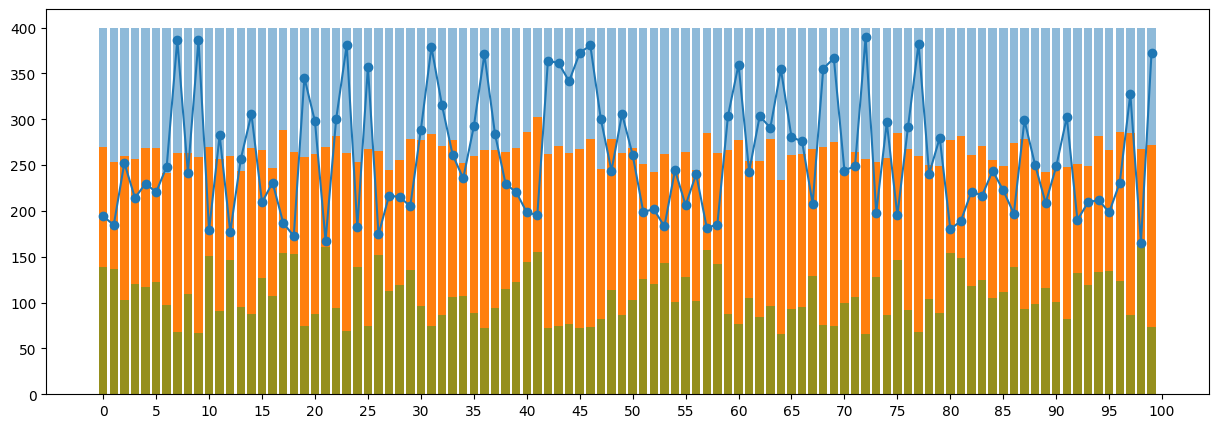

263.92


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(15, 5))
x = list(range(TEST_NUM))
plt.bar(x, evaluator.board_sizes, alpha=0.5)
plt.bar(x, evaluator.scores)
plt.bar(x, evaluator.ans_points, alpha=0.5)
plt.plot(x, np.array(evaluator.scores) / np.array(evaluator.ans_points) * 100, marker="o")
plt.xticks(range(0, len(evaluator.scores)+1, 5))
plt.show()

print(sum(evaluator.scores) / len(evaluator.scores))